In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("monthly_milk_production.csv")

# Convert to datetime
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 168 entries, 1962-01-01 to 1975-12-01
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Production  168 non-null    int64
dtypes: int64(1)
memory usage: 2.6 KB
None
       Production
count  168.000000
mean   754.708333
std    102.204524
min    553.000000
25%    677.750000
50%    761.000000
75%    824.500000
max    969.000000


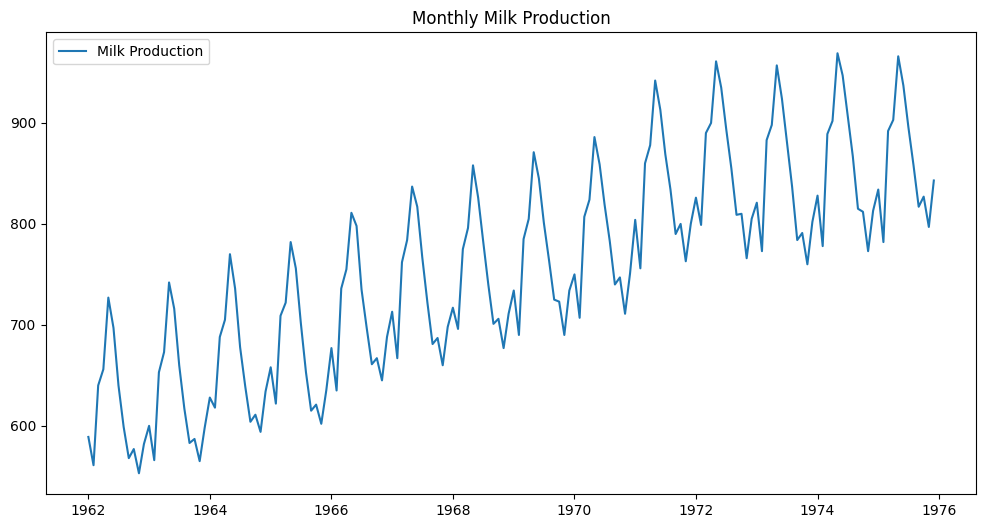

In [6]:
#Plot time series
plt.figure(figsize=(12,6))
plt.plot(df, label='Milk Production')
plt.title("Monthly Milk Production")
plt.legend()
plt.show()

In [7]:
print(df.isnull().sum())

Production    0
dtype: int64


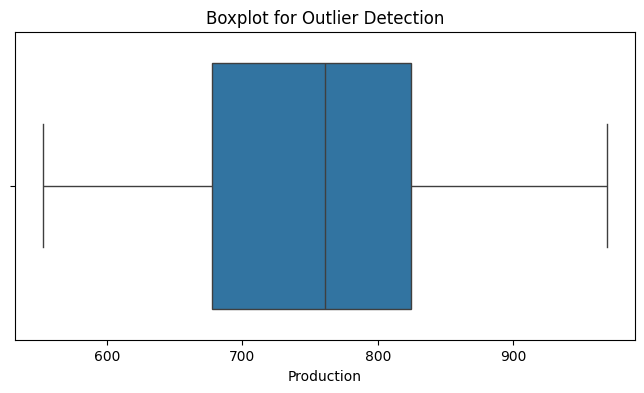

In [8]:
# Outlier Detection using Boxplot
plt.figure(figsize=(8,4))
sns.boxplot(x=df['Production'])
plt.title("Boxplot for Outlier Detection")
plt.show()

# IQR Method
Q1 = df['Production'].quantile(0.25)
Q3 = df['Production'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Capping outliers
df['Production'] = np.where(df['Production'] > upper, upper,
                            np.where(df['Production'] < lower, lower,
                                     df['Production']))

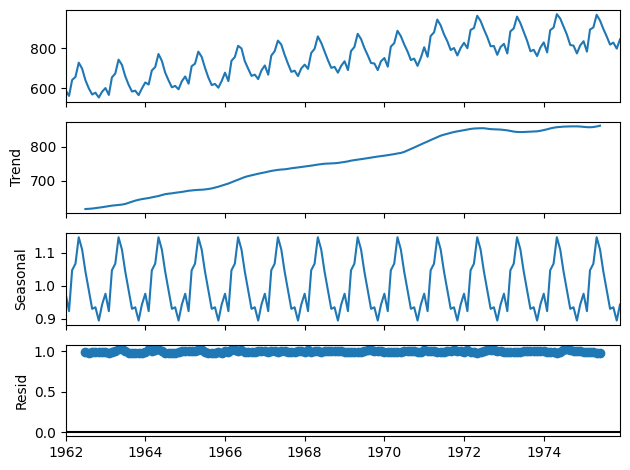

In [9]:
#check seasonality
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(df, model='multiplicative')
decomposition.plot()
plt.show()

In [10]:
#scaling
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)

In [11]:
#Create Sequences
import numpy as np

def create_sequences(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])
    return np.array(X), np.array(y)

window_size = 12
X, y = create_sequences(scaled_data, window_size)

In [12]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU

In [14]:
#RNN Model
rnn_model = Sequential([
    SimpleRNN(50, activation='relu', input_shape=(window_size,1)),
    Dense(1)
])

rnn_model.compile(optimizer='adam', loss='mse')
rnn_model.fit(X_train, y_train, epochs=20, batch_size=16)



Epoch 1/20

8/8 [==============================] - 9s 21ms/step - loss: 0.1650
Epoch 2/20
8/8 [==============================] - 0s 9ms/step - loss: 0.0340
Epoch 3/20
8/8 [==============================] - 0s 8ms/step - loss: 0.0237
Epoch 4/20
8/8 [==============================] - 0s 9ms/step - loss: 0.0190
Epoch 5/20
8/8 [==============================] - 0s 7ms/step - loss: 0.0165
Epoch 6/20
8/8 [==============================] - 0s 9ms/step - loss: 0.0141
Epoch 7/20
8/8 [==============================] - 0s 9ms/step - loss: 0.0123
Epoch 8/20
8/8 [==============================] - 0s 7ms/step - loss: 0.0105
Epoch 9/20
8/8 [==============================] - 0s 7ms/step - loss: 0.0091
Epoch 10/20
8/8 [==============================] - 0s 7ms/step - loss: 0.0078
Epoch 11/20
8/8 [==============================] - 0s 7ms/step - loss: 0.0064
Epoch 12/20
8/8 [==============================] - 0s 7ms/step - loss: 0.0057
Epoch 13/20
8/8 [==============================] - 0s 7ms/step - loss

In [15]:
#LSTM Model
lstm_model = Sequential([
    LSTM(50, activation='relu', input_shape=(window_size,1)),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.fit(X_train, y_train, epochs=20, batch_size=16)

Epoch 1/20
8/8 [==============================] - 4s 12ms/step - loss: 0.2426
Epoch 2/20
8/8 [==============================] - 0s 12ms/step - loss: 0.1485
Epoch 3/20
8/8 [==============================] - 0s 12ms/step - loss: 0.0731
Epoch 4/20
8/8 [==============================] - 0s 12ms/step - loss: 0.0297
Epoch 5/20
8/8 [==============================] - 0s 11ms/step - loss: 0.0286
Epoch 6/20
8/8 [==============================] - 0s 13ms/step - loss: 0.0224
Epoch 7/20
8/8 [==============================] - 0s 9ms/step - loss: 0.0233
Epoch 8/20
8/8 [==============================] - 0s 11ms/step - loss: 0.0218
Epoch 9/20
8/8 [==============================] - 0s 12ms/step - loss: 0.0217
Epoch 10/20
8/8 [==============================] - 0s 12ms/step - loss: 0.0217
Epoch 11/20
8/8 [==============================] - 0s 12ms/step - loss: 0.0213
Epoch 12/20
8/8 [==============================] - 0s 12ms/step - loss: 0.0211
Epoch 13/20
8/8 [==============================] - 0s 12ms/ste

In [16]:
#GRU Model
gru_model = Sequential([
    GRU(50, activation='relu', input_shape=(window_size,1)),
    Dense(1)
])

gru_model.compile(optimizer='adam', loss='mse')
gru_model.fit(X_train, y_train, epochs=20, batch_size=16)

Epoch 1/20
8/8 [==============================] - 3s 12ms/step - loss: 0.1857
Epoch 2/20
8/8 [==============================] - 0s 10ms/step - loss: 0.1168
Epoch 3/20
8/8 [==============================] - 0s 9ms/step - loss: 0.0681
Epoch 4/20
8/8 [==============================] - 0s 10ms/step - loss: 0.0345
Epoch 5/20
8/8 [==============================] - 0s 11ms/step - loss: 0.0250
Epoch 6/20
8/8 [==============================] - 0s 12ms/step - loss: 0.0260
Epoch 7/20
8/8 [==============================] - 0s 11ms/step - loss: 0.0226
Epoch 8/20
8/8 [==============================] - 0s 12ms/step - loss: 0.0220
Epoch 9/20
8/8 [==============================] - 0s 12ms/step - loss: 0.0209
Epoch 10/20
8/8 [==============================] - 0s 11ms/step - loss: 0.0199
Epoch 11/20
8/8 [==============================] - 0s 11ms/step - loss: 0.0196
Epoch 12/20
8/8 [==============================] - 0s 12ms/step - loss: 0.0191
Epoch 13/20
8/8 [==============================] - 0s 11ms/ste

In [17]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

def evaluate_model(model, X_test, y_test):
    predictions = model.predict(X_test)
    
    predictions = scaler.inverse_transform(predictions)
    y_test_actual = scaler.inverse_transform(y_test)
    
    rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
    mae = mean_absolute_error(y_test_actual, predictions)
    mape = np.mean(np.abs((y_test_actual - predictions) / y_test_actual)) * 100
    
    return rmse, mae, mape, predictions, y_test_actual

In [18]:
rnn_metrics = evaluate_model(rnn_model, X_test, y_test)
lstm_metrics = evaluate_model(lstm_model, X_test, y_test)
gru_metrics = evaluate_model(gru_model, X_test, y_test)

print("RNN:", rnn_metrics[:3])
print("LSTM:", lstm_metrics[:3])
print("GRU:", gru_metrics[:3])

1/1 [==============================] - 0s 402ms/step
RNN: (24.10445105838612, 18.666248321533192, 2.2112086299143)
LSTM: (57.7683458958386, 50.821603775024414, 5.980239992017846)
GRU: (51.62630216748184, 42.19847679138182, 4.841529432797209)


In [23]:
# Model Comparison Table
comparison = pd.DataFrame({
    'Model': ['RNN', 'LSTM', 'GRU'],
    'RMSE': [rnn_metrics[0], lstm_metrics[0], gru_metrics[0]],
    'MAE': [rnn_metrics[1], lstm_metrics[1], gru_metrics[1]],
    'MAPE': [rnn_metrics[2], lstm_metrics[2], gru_metrics[2]]
})

print(comparison)

  Model       RMSE        MAE      MAPE
0   RNN  24.104451  18.666248  2.211209
1  LSTM  57.768346  50.821604  5.980240
2   GRU  51.626302  42.198477  4.841529


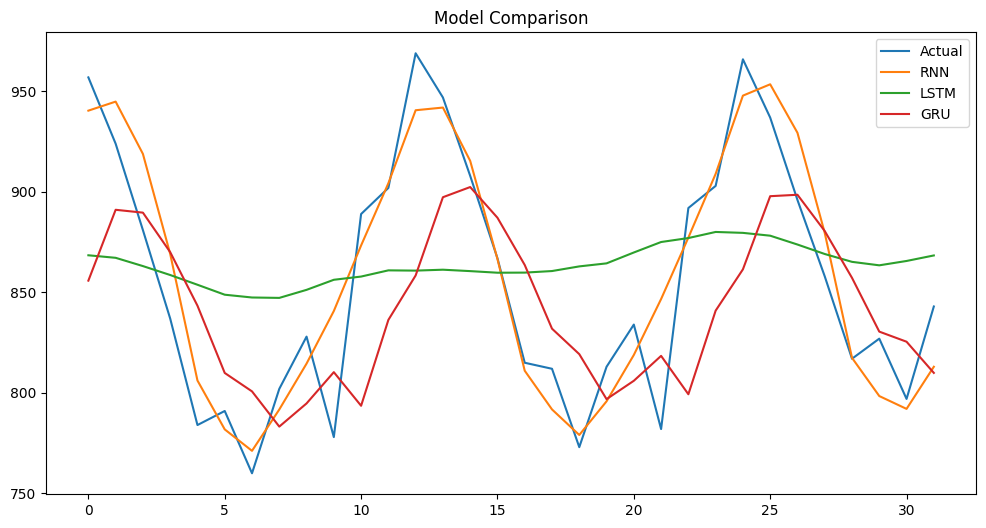

In [19]:
#Plot Predictions
plt.figure(figsize=(12,6))
plt.plot(rnn_metrics[4], label="Actual")
plt.plot(rnn_metrics[3], label="RNN")
plt.plot(lstm_metrics[3], label="LSTM")
plt.plot(gru_metrics[3], label="GRU")
plt.legend()
plt.title("Model Comparison")
plt.show()

In [20]:
#Future Forecast
def forecast(model, data, window_size, steps):
    temp_input = data[-window_size:].reshape(1, window_size, 1)
    forecast = []

    for _ in range(steps):
        pred = model.predict(temp_input)[0]
        forecast.append(pred)
        
        temp_input = np.append(temp_input[:,1:,:], [[pred]], axis=1)
    
    return scaler.inverse_transform(forecast)

future_preds = forecast(lstm_model, scaled_data, window_size, 12)

1/1 [==============================] - 0s 53ms/step


C:\Users\SUGANYA P\AppData\Local\Temp\ipykernel_26056\4051942340.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  plt.plot(pd.date_range(df.index[-1], periods=13, freq='M')[1:], future_preds, label="Forecast")


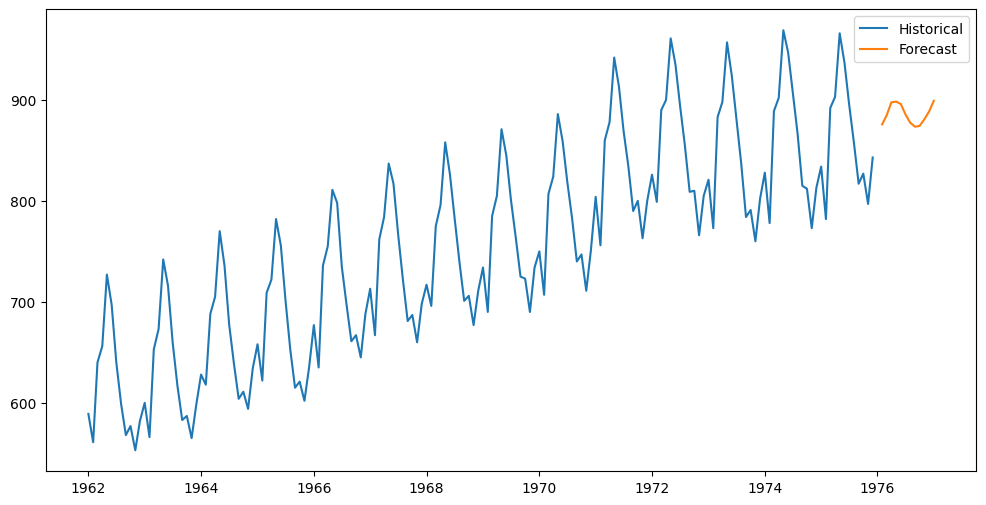

In [21]:
#Plot Forecast
plt.figure(figsize=(12,6))
plt.plot(df, label="Historical")
plt.plot(pd.date_range(df.index[-1], periods=13, freq='M')[1:], future_preds, label="Forecast")
plt.legend()
plt.show()

In [22]:
configs = [
    {'units': 32, 'epochs': 20, 'batch': 16},
    {'units': 50, 'epochs': 30, 'batch': 16},
    {'units': 64, 'epochs': 20, 'batch': 32}
]

results = []

for config in configs:
    model = Sequential([
        LSTM(config['units'], activation='relu', input_shape=(window_size,1)),
        Dense(1)
    ])
    
    model.compile(optimizer='adam', loss='mse')
    
    model.fit(X_train, y_train,
              epochs=config['epochs'],
              batch_size=config['batch'],
              verbose=0)
    
    rmse, mae, mape, _, _ = evaluate_model(model, X_test, y_test)
    
    results.append((config, rmse))

print("Hyperparameter Tuning Results:")
for config, rmse in results:
    print(config, "-> RMSE:", rmse)

1/1 [==============================] - 0s 392ms/step
Hyperparameter Tuning Results:
{'units': 32, 'epochs': 20, 'batch': 16} -> RMSE: 40.36963357478639
{'units': 50, 'epochs': 30, 'batch': 16} -> RMSE: 56.824070129798116
{'units': 64, 'epochs': 20, 'batch': 32} -> RMSE: 62.04558628576412
